In [1]:
!pip install -q ultralytics roboflow

In [2]:
from ultralytics import YOLO
from roboflow import Roboflow
from google.colab import files
import matplotlib.pyplot as plt
from PIL import Image
import glob
import torch

In [3]:
print("CUDA :", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA : True
Tesla T4


In [4]:
from roboflow import Roboflow

rf = Roboflow(api_key="yUvBQJoOOj2EHZC2Tytu")

project = rf.workspace("bagus-hermawan").project("indonesia-rupiah-detection-z8ebn")

version = project.version(1)

dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [5]:
model = YOLO("yolov8n.pt")

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Indonesia-Rupiah-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x796f297a4650>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

In [6]:
model = YOLO("/content/runs/detect/train/weights/best.pt")

In [7]:
uploaded = files.upload()

Saving uang.jpeg to uang (2).jpeg


In [8]:
results = model.predict(
    source="uang.jpeg",
    conf=0.05,
    save=True
)


image 1/1 /content/uang.jpeg: 640x384 1 money 10000, 1 money 100000, 40.9ms
Speed: 3.1ms preprocess, 40.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/runs/detect/predict-5


In [9]:
for r in results:
    print("Jumlah objek:", len(r.boxes))

Jumlah objek: 2


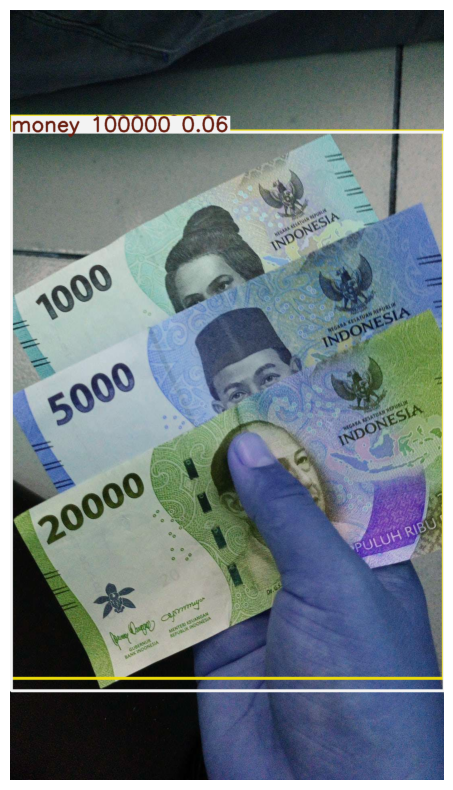

In [10]:
for r in results:
    img = r.plot()

    plt.figure(figsize=(10,10))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [11]:
for r in results:
    for box in r.boxes:
        cls = int(box.cls)
        conf = float(box.conf)

        print("Nominal :", model.names[cls])
        print("Confidence :", round(conf*100,2), "%")
        print("-----------------------")

Nominal : money 100000
Confidence : 6.21 %
-----------------------
Nominal : money 10000
Confidence : 5.58 %
-----------------------


In [12]:
files.download("/content/runs/detect/train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")